MV buses: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Converged: 96/96
Minimum voltage range: 0.9346261116291623 to 0.9885961995696146
Maximum line loading range: 30.361583755638467 to 80.4424754115863
Maximum transformer loading range: 52.96504784906345 to 98.45883655415516
External-grid power range (MW): 25.06055675794879 to 44.54115775018177


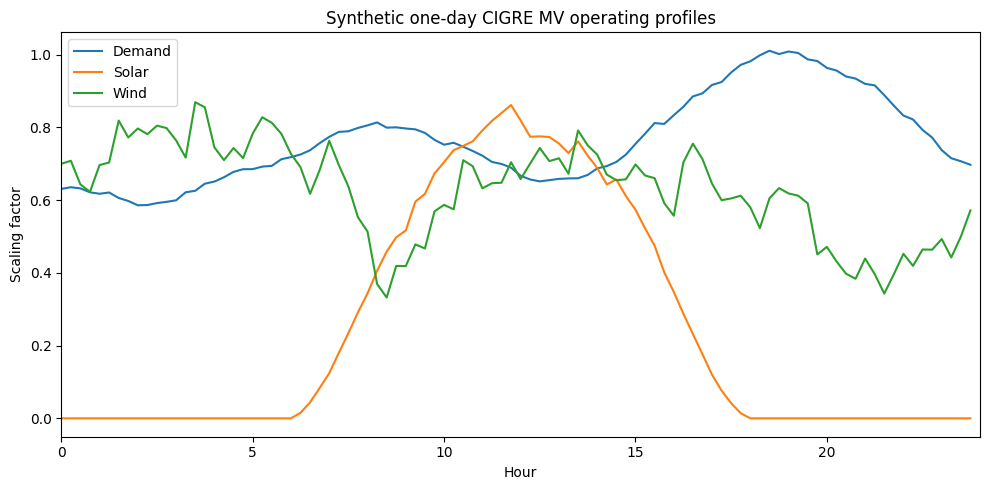

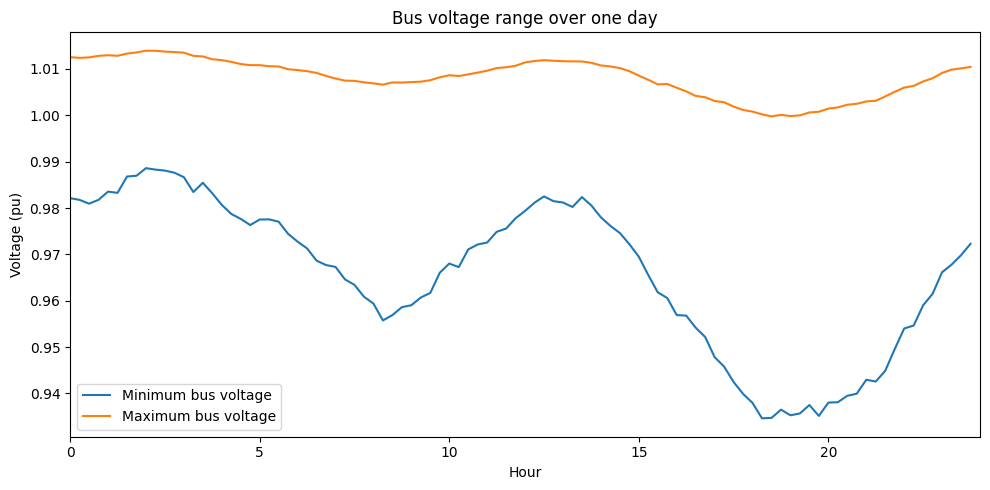

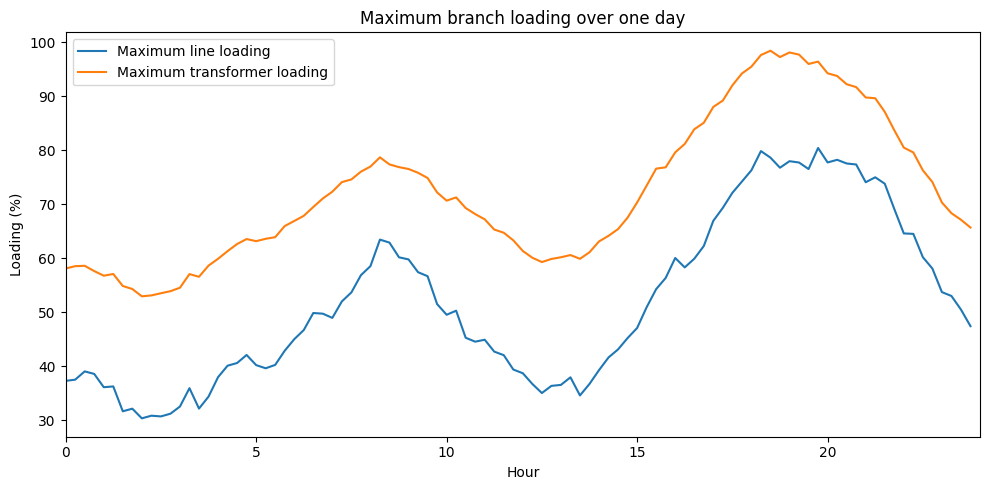

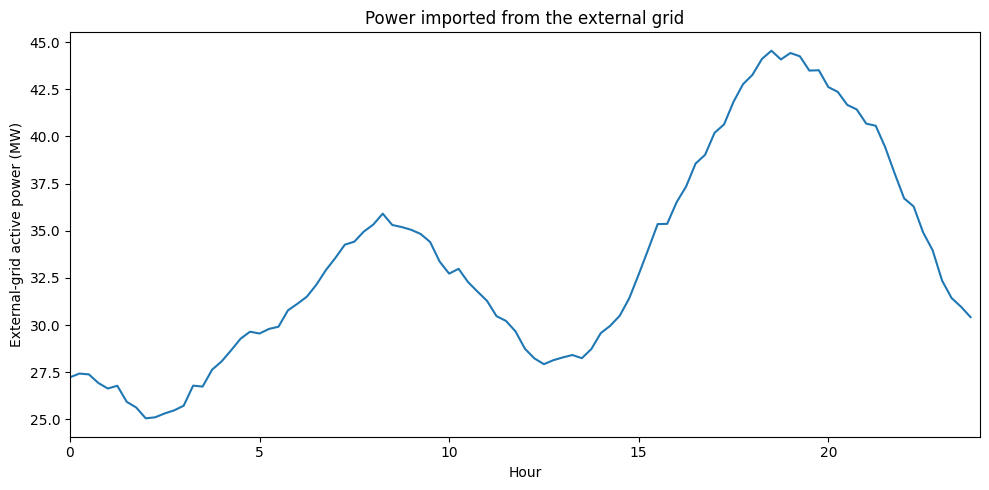

In [1]:
"""Generate a simple one-day operating profile for the CIGRE MV grid.

This is an exploratory data-generation spike, not the final dataset generator.
It varies three scalar controls over a day:

* demand scaling for every load
* solar scaling for the eight PV generators
* wind scaling for the single wind generator

Each 15-minute operating state is solved independently with pandapower AC power
flow and a few diagnostic quantities are recorded.
"""

from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandapower as pp
from pandapower.auxiliary import LoadflowNotConverged
from pandapower.networks import create_cigre_network_mv


STEPS_PER_DAY = 96


@dataclass(frozen=True)
class Profiles:
    hours: np.ndarray
    demand: np.ndarray
    solar: np.ndarray
    wind: np.ndarray


@dataclass(frozen=True)
class PowerFlowResults:
    min_voltage_pu: np.ndarray
    max_voltage_pu: np.ndarray
    max_line_loading_percent: np.ndarray
    max_trafo_loading_percent: np.ndarray
    external_grid_p_mw: np.ndarray
    converged: np.ndarray


def _smooth_noise(
    rng: np.random.Generator,
    n: int,
    *,
    scale: float,
    window: int,
) -> np.ndarray:
    """Return low-frequency zero-mean noise."""
    noise = rng.normal(0.0, scale, size=n + window - 1)
    kernel = np.ones(window) / window
    return np.convolve(noise, kernel, mode="valid")


def make_one_day_profiles(seed: int = 0) -> Profiles:
    """Create simple, correlated demand/solar/wind profiles for one day."""
    rng = np.random.default_rng(seed)
    hours = np.arange(STEPS_PER_DAY) * 24.0 / STEPS_PER_DAY

    # Demand: low overnight, a smaller morning peak, and a larger evening peak.
    morning_peak = 0.18 * np.exp(-0.5 * ((hours - 8.0) / 2.0) ** 2)
    evening_peak = 0.38 * np.exp(-0.5 * ((hours - 19.0) / 2.7) ** 2)
    demand = 0.62 + morning_peak + evening_peak
    demand += _smooth_noise(rng, STEPS_PER_DAY, scale=0.04, window=7)
    demand = np.clip(demand, 0.50, 1.10)

    # Solar: zero outside 06:00-18:00 and approximately bell-shaped in daylight.
    daylight_phase = np.pi * (hours - 6.0) / 12.0
    clear_sky = np.where(
        (hours >= 6.0) & (hours <= 18.0),
        np.maximum(np.sin(daylight_phase), 0.0) ** 1.5,
        0.0,
    )
    cloud_factor = 0.90 + _smooth_noise(
        rng, STEPS_PER_DAY, scale=0.18, window=9
    )
    solar = np.clip(clear_sky * cloud_factor, 0.0, 1.0)

    # Wind: a slowly varying stochastic process, not tied to time of day.
    wind = np.empty(STEPS_PER_DAY)
    wind[0] = 0.70
    mean = 0.70
    persistence = 0.94
    innovation_scale = 0.05
    for t in range(1, STEPS_PER_DAY):
        wind[t] = (
            mean
            + persistence * (wind[t - 1] - mean)
            + rng.normal(0.0, innovation_scale)
        )
    wind = np.clip(wind, 0.15, 1.10)

    return Profiles(hours=hours, demand=demand, solar=solar, wind=wind)


def plot_profiles(profiles: Profiles) -> None:
    """Plot the three exogenous operating profiles."""
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(profiles.hours, profiles.demand, label="Demand")
    ax.plot(profiles.hours, profiles.solar, label="Solar")
    ax.plot(profiles.hours, profiles.wind, label="Wind")
    ax.set(
        xlabel="Hour",
        ylabel="Scaling factor",
        title="Synthetic one-day CIGRE MV operating profiles",
        xlim=(0, 24),
    )
    ax.legend()
    fig.tight_layout()


def run_one_day(profiles: Profiles) -> PowerFlowResults:
    """Apply each profile state to the CIGRE MV grid and solve AC power flow."""
    net = create_cigre_network_mv(with_der="pv_wind")

    pv = net.sgen["name"].str.startswith("PV")
    wind = net.sgen["name"].str.startswith("WKA")

    # Buses whose voltage limits we want to assess.
    mv_buses = net.bus.index[net.bus["vn_kv"] == 20.0]
    print("MV buses:", mv_buses.tolist())

    n = len(profiles.hours)
    min_voltage_pu = np.full(n, np.nan)
    max_voltage_pu = np.full(n, np.nan)
    max_line_loading_percent = np.full(n, np.nan)
    max_trafo_loading_percent = np.full(n, np.nan)
    external_grid_p_mw = np.full(n, np.nan)
    converged = np.zeros(n, dtype=bool)

    for t in range(n):
        net.load.loc[:, "scaling"] = profiles.demand[t]
        net.sgen.loc[pv, "scaling"] = profiles.solar[t]
        net.sgen.loc[wind, "scaling"] = profiles.wind[t]

        try:
            pp.runpp(net, init="auto")
        except LoadflowNotConverged:
            continue

        converged[t] = True

        mv_voltages = net.res_bus.loc[mv_buses, "vm_pu"]

        min_voltage_pu[t] = mv_voltages.min()
        max_voltage_pu[t] = mv_voltages.max()

        max_line_loading_percent[t] = net.res_line["loading_percent"].max()
        max_trafo_loading_percent[t] = net.res_trafo["loading_percent"].max()
        external_grid_p_mw[t] = net.res_ext_grid["p_mw"].sum()

    return PowerFlowResults(
        min_voltage_pu=min_voltage_pu,
        max_voltage_pu=max_voltage_pu,
        max_line_loading_percent=max_line_loading_percent,
        max_trafo_loading_percent=max_trafo_loading_percent,
        external_grid_p_mw=external_grid_p_mw,
        converged=converged,
    )


def plot_power_flow_results(
    profiles: Profiles,
    results: PowerFlowResults,
) -> None:
    """Plot the main physical outputs from the solved operating states."""
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(profiles.hours, results.min_voltage_pu, label="Minimum bus voltage")
    ax.plot(profiles.hours, results.max_voltage_pu, label="Maximum bus voltage")
    ax.set(
        xlabel="Hour",
        ylabel="Voltage (pu)",
        title="Bus voltage range over one day",
        xlim=(0, 24),
    )
    ax.legend()
    fig.tight_layout()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(
        profiles.hours,
        results.max_line_loading_percent,
        label="Maximum line loading",
    )
    ax.plot(
        profiles.hours,
        results.max_trafo_loading_percent,
        label="Maximum transformer loading",
    )
    ax.set(
        xlabel="Hour",
        ylabel="Loading (%)",
        title="Maximum branch loading over one day",
        xlim=(0, 24),
    )
    ax.legend()
    fig.tight_layout()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(profiles.hours, results.external_grid_p_mw)
    ax.set(
        xlabel="Hour",
        ylabel="External-grid active power (MW)",
        title="Power imported from the external grid",
        xlim=(0, 24),
    )
    fig.tight_layout()


def print_summary(results: PowerFlowResults) -> None:
    """Print a small sanity-check summary."""
    n_total = len(results.converged)
    n_converged = int(results.converged.sum())

    print(f"Converged: {n_converged}/{n_total}")
    if n_converged == 0:
        return

    print(
        "Minimum voltage range:",
        float(np.nanmin(results.min_voltage_pu)),
        "to",
        float(np.nanmax(results.min_voltage_pu)),
    )
    print(
        "Maximum line loading range:",
        float(np.nanmin(results.max_line_loading_percent)),
        "to",
        float(np.nanmax(results.max_line_loading_percent)),
    )
    print(
        "Maximum transformer loading range:",
        float(np.nanmin(results.max_trafo_loading_percent)),
        "to",
        float(np.nanmax(results.max_trafo_loading_percent)),
    )
    print(
        "External-grid power range (MW):",
        float(np.nanmin(results.external_grid_p_mw)),
        "to",
        float(np.nanmax(results.external_grid_p_mw)),
    )


def main() -> None:
    profiles = make_one_day_profiles(seed=0)
    plot_profiles(profiles)

    results = run_one_day(profiles)
    print_summary(results)
    plot_power_flow_results(profiles, results)

    plt.show()
    return results, profiles

results, profiles = main()


Dominant constraint
low_voltage: 37
trafo_loading: 59
Security margin range: -0.30747776741675253 to 0.4703495215093655
States violating a limit: 20 / 96


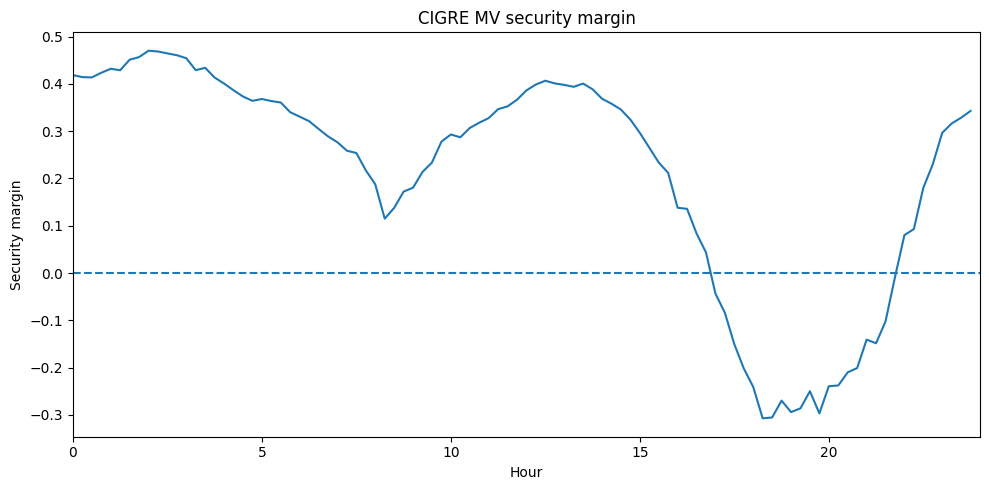

In [2]:
V_MIN = 0.95
V_MAX = 1.05
MAX_LOADING_PERCENT = 100.0


low_voltage_margin = (
    results.min_voltage_pu - V_MIN
) / (1.0 - V_MIN)

high_voltage_margin = (
    V_MAX - results.max_voltage_pu
) / (V_MAX - 1.0)

line_margin = (
    1.0 - results.max_line_loading_percent / 100.0
)

trafo_margin = (
    1.0 - results.max_trafo_loading_percent / 100.0
)

security_margin = np.minimum.reduce(
    [
        low_voltage_margin,
        high_voltage_margin,
        line_margin,
        trafo_margin,
    ]
)


margins = np.stack(
    [
        low_voltage_margin,
        high_voltage_margin,
        line_margin,
        trafo_margin,
    ],
    axis=1,
)

constraint_names = np.array(
    [
        "low_voltage",
        "high_voltage",
        "line_loading",
        "trafo_loading",
    ]
)

dominant = constraint_names[np.argmin(margins, axis=1)]

names, counts = np.unique(dominant, return_counts=True)

print("\nDominant constraint")
for name, count in zip(names, counts, strict=True):
    print(f"{name}: {count}")


print(
    "Security margin range:",
    security_margin.min(),
    "to",
    security_margin.max(),
)

print(
    "States violating a limit:",
    np.sum(security_margin < 0),
    "/",
    len(security_margin),
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(profiles.hours, security_margin)
ax.axhline(0.0, linestyle="--")

ax.set(
    xlabel="Hour",
    ylabel="Security margin",
    title="CIGRE MV security margin",
    xlim=(0, 24),
)

fig.tight_layout()

In [3]:
for name in ["low_voltage", "trafo_loading"]:
    mask = dominant == name

    print(f"\n{name}")
    print("count:", mask.sum())
    print("mean demand:", profiles.demand[mask].mean())
    print("mean solar:", profiles.solar[mask].mean())
    print("mean wind:", profiles.wind[mask].mean())
    print("mean margin:", security_margin[mask].mean())


low_voltage
count: 37
mean demand: 0.8920779298077961
mean solar: 0.1465669650497119
mean wind: 0.5136843649139039
mean margin: -0.03694248674378858

trafo_loading
count: 59
mean demand: 0.6852344350563917
mean solar: 0.3033636022310645
mean wind: 0.6987784707438166
mean margin: 0.3653964580635878


In [4]:
violating = security_margin < 0

print("\nViolating states")
print("count:", violating.sum())
print("mean demand:", profiles.demand[violating].mean())
print("mean solar:", profiles.solar[violating].mean())
print("mean wind:", profiles.wind[violating].mean())


Violating states
count: 20
mean demand: 0.9558247087132175
mean solar: 0.012568773553071996
mean wind: 0.5167512260572227
